## Random forest classifier — comparator model

A random forest model is trained on the same preprocessed data as the logistic regression to assess whether a more complex ensemble approach offers meaningful performance gains. The tradeoff between predictive performance and clinical interpretability is discussed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay)
import shap

df = pd.read_csv('data/cvd_synthetic_dataset_v0.2.csv')

df_model = df.drop(columns=['patient_id', 'time_to_event_or_censoring'])
df_model['gender'] = df_model['gender'].map({'M': 1, 'F': 0})

X = df_model.drop(columns=['heart_attack_or_stroke_occurred'])
y = df_model['heart_attack_or_stroke_occurred']

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

scaler = StandardScaler()
continuous_cols_model = ['age', 'body_mass_index', 'systolic_blood_pressure', 'forced_expiratory_volume_1']
X_imputed[continuous_cols_model] = scaler.fit_transform(X_imputed[continuous_cols_model])

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

print("Data ready.")

Data ready.


In [2]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(f"AUC-ROC: {round(roc_auc_score(y_test, y_prob_rf), 3)}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_rf, target_names=['No event', 'Event']))

AUC-ROC: 0.77

Classification report:
              precision    recall  f1-score   support

    No event       0.94      0.99      0.96     18678
       Event       0.19      0.05      0.07      1322

    accuracy                           0.92     20000
   macro avg       0.56      0.52      0.52     20000
weighted avg       0.89      0.92      0.90     20000



### Random forest results

**AUC-ROC: 0.77** — notably lower than the logistic regression (0.83), indicating weaker overall discriminative ability despite being a more complex model.

**Sensitivity (recall) for events: 0.05** — the model correctly identifies only 5% of patients who will experience an event, compared to 80% for logistic regression. This is a dramatic difference and represents a near-complete failure to detect the minority class.

**Accuracy: 0.92** — superficially impressive but deeply misleading. The model achieves this by predicting "no event" for almost every patient, correctly labelling the 93.4% majority class while missing virtually all true cases. This illustrates precisely why accuracy is an inappropriate metric for imbalanced datasets.

**Why does the random forest underperform here?**

Despite using class_weight='balanced', the random forest has defaulted towards predicting the majority class. This is a known behaviour in ensemble methods on heavily imbalanced datasets — individual trees may still be biased towards the majority class, and aggregating 100 such trees compounds this tendency. Techniques such as resampling (SMOTE) or adjusting the classification threshold could improve minority class detection, but this is beyond the scope of this project.

**The interpretability tradeoff:**

Beyond performance, the random forest is considerably less interpretable than logistic regression. A logistic regression coefficient can be explained to a clinician in straightforward terms — "each additional year of age increases the log-odds of an event by X." A random forest offers no equivalent transparency, which is a significant barrier in clinical settings where decisions must be explainable and auditable.

**Conclusion:** For this dataset and clinical context, logistic regression is the superior model — not only performing better on the most clinically important metric (sensitivity) but also offering the interpretability required for NHS deployment. This finding reinforces a broader principle in clinical AI: model complexity does not guarantee better performance, and interpretability should be weighted heavily in healthcare contexts.

C:\Users\Aaron\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\Aaron\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


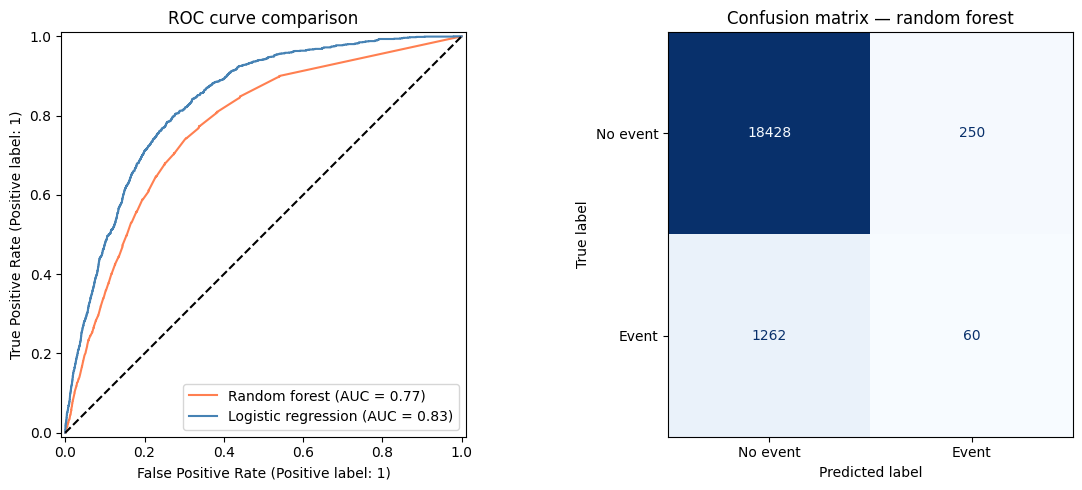

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC curve comparison
RocCurveDisplay.from_predictions(
    y_test, y_prob_rf, ax=axes[0], 
    color='coral', name='Random forest'
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay

lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(
    y_test, y_prob_lr, ax=axes[0],
    color='steelblue', name='Logistic regression'
)
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('ROC curve comparison')

# Confusion matrix - random forest
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['No event', 'Event'],
    ax=axes[1],
    colorbar=False,
    cmap='Blues'
)
axes[1].set_title('Confusion matrix — random forest')

plt.tight_layout()
plt.show()

### ROC curve comparison and confusion matrix

**ROC curve:** The logistic regression curve (blue) sits consistently above the random forest curve (coral) across the entire range, confirming its superior discriminative ability at every operating point. The gap is most pronounced in the clinically relevant region of low false positive rates (left side of the curve), where a screening tool would ideally operate.

**Confusion matrix — random forest:** The numbers make the failure of the random forest on this task stark. Of 1,322 patients who experienced an event, the model correctly identified only 60 — missing 1,262 true cases. In a clinical screening context this is an unacceptable false negative rate of 95%. For every patient correctly identified as high risk, 21 true cases were missed.

**Head to head comparison:**

| Metric | Logistic regression | Random forest |
|---|---|---|
| AUC-ROC | 0.83 | 0.77 |
| Sensitivity | 0.80 | 0.05 |
| Specificity | 0.73 | 0.99 |
| False negatives | 267 | 1,262 |
| False positives | 5,107 | 250 |

The random forest trades almost all sensitivity for specificity — it almost never flags a patient as high risk, which means it almost never makes a false positive, but at the cost of missing 95% of true cases. This is the wrong tradeoff for a screening tool where the clinical priority is identifying patients at risk.

**Final model selection:** The logistic regression is selected as the preferred model for this task on the basis of superior AUC-ROC, dramatically better sensitivity, and inherent interpretability. This outcome reinforces the principle that in clinical AI, simpler interpretable models should always be evaluated before more complex alternatives — and that complexity does not guarantee better performance.